# 06 - Forecasting Models

**Purpose:** compare baselines and scikit-learn models for two tasks:

- next-month review-count regression;
- attention-pulse classification.

The main comparison is whether stronger model families, probability diagnostics, and reduced feature sets improve on the earlier Random Forest ablations while keeping the workflow interpretable.

In [1]:
# Load modeling data, define output paths, and import sklearn model families.
from pathlib import Path
import json

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import (
    HistGradientBoostingClassifier,
    HistGradientBoostingRegressor,
    RandomForestClassifier,
    RandomForestRegressor,
)
from sklearn.feature_selection import SelectKBest, f_classif, f_regression
from sklearn.linear_model import LogisticRegression, PoissonRegressor
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    brier_score_loss,
    f1_score,
    mean_absolute_error,
    mean_squared_error,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed" / "new_orleans"
OUTPUTS_DIR = PROJECT_ROOT / "outputs"
FIGURES_DIR = OUTPUTS_DIR / "figures" / "models"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)

FORECASTING_DATASET_PATH = PROCESSED_DIR / "forecasting_dataset.csv"
COHORT_BUSINESSES_PATH = PROCESSED_DIR / "forecasting_cohort_businesses.csv"
METRICS_OUTPUT_PATH = OUTPUTS_DIR / "forecasting_metrics.csv"
PREDICTIONS_OUTPUT_PATH = OUTPUTS_DIR / "forecasting_predictions.csv"
PULSE_METRICS_OUTPUT_PATH = OUTPUTS_DIR / "attention_pulse_metrics.csv"
PULSE_PREDICTIONS_OUTPUT_PATH = OUTPUTS_DIR / "attention_pulse_predictions.csv"
PULSE_TOPK_OUTPUT_PATH = OUTPUTS_DIR / "attention_pulse_topk_metrics.csv"
PULSE_CALIBRATION_OUTPUT_PATH = OUTPUTS_DIR / "attention_pulse_calibration.csv"

plt.rcParams.update({"figure.figsize": (10, 5), "axes.grid": True, "grid.alpha": 0.25, "axes.spines.top": False, "axes.spines.right": False})
modeling = pd.read_csv(FORECASTING_DATASET_PATH)
business_lookup = pd.read_csv(COHORT_BUSINESSES_PATH)[["business_id", "name", "categories"]]
print(modeling.shape)
modeling.head()

(68249, 111)


,business_id,monthly_review_count,monthly_star_sum,prev_month_reviews,rolling_3_avg,rolling_6_avg,same_month_previous_year,cumulative_review_count,cumulative_star_sum,avg_rating_history,...,feature_month_str,target_month_str,calendar_month,month_sin,month_cos,feature_month_number,pulse_baseline_reviews,pulse_relative_lift,attention_pulse,first_active_feature_month_str
0,-1XSzguS6XLN-V6MVZMg2A,6,29.0,6,2.000000,1.000000,0.0,6,29.0,4.833333,...,2015-12,2016-01,12,-2.449294e-16,1.000000e+00,12,1.000000,6.000000,1,2015-12
1,-1XSzguS6XLN-V6MVZMg2A,6,30.0,6,4.000000,2.000000,0.0,12,59.0,4.916667,...,2016-01,2016-02,1,5.000000e-01,8.660254e-01,13,2.000000,8.500000,1,2015-12
2,-1XSzguS6XLN-V6MVZMg2A,17,84.0,17,9.666667,4.833333,0.0,29,143.0,4.931034,...,2016-02,2016-03,2,8.660254e-01,5.000000e-01,14,4.833333,2.896552,1,2015-12
3,-1XSzguS6XLN-V6MVZMg2A,14,67.0,14,12.333333,7.166667,0.0,43,210.0,4.883721,...,2016-03,2016-04,3,1.000000e+00,6.123234e-17,15,7.166667,2.790698,1,2015-12
4,-1XSzguS6XLN-V6MVZMg2A,20,97.0,20,17.000000,10.500000,0.0,63,307.0,4.873016,...,2016-04,2016-05,4,8.660254e-01,-5.000000e-01,16,10.500000,1.142857,0,2015-12


## Chronological Split

The modeling question is now restricted to normal monthly review activity before the COVID-era disruption. The single evaluation split uses three chronological periods:

- **train:** 2015-2017, used to fit the model;
- **validation:** 2018, used only for attention-pulse threshold tuning;
- **test:** 2019, used for final reported performance.

This keeps the final test period in the same broad operating regime as the training data, so the metrics estimate ordinary pre-COVID forecast performance rather than shock robustness.

## Feature Groups

Compare interpretable modality groups: historical review behavior, business metadata, SNA exposure, NLP text signals, and all modalities combined.

The NLP group automatically includes the capped TF-IDF topic indicators generated in notebook `05`, so the ablation tests whether recent review language adds signal beyond counts and metadata.

## Attention-Pulse Models

Pulse models are evaluated in three ways:

- thresholded classification metrics using a validation-tuned cutoff;
- top-k retrieval metrics, which ask whether the model can surface the most likely 5%, 10%, or 20% of future attention pulses;
- probability diagnostics using Brier score and calibration bins.

Because pulses are rare, F1, PR-AUC, precision@k, recall@k, and calibration are more informative than accuracy alone.

In [2]:
# Define metrics, split helpers, model builders, and feature groups.
def wape(y_true, y_pred):
    denominator = np.sum(np.abs(y_true))
    return np.nan if denominator == 0 else np.sum(np.abs(y_true - y_pred)) / denominator


def safe_auc(metric_fn, y_true, score):
    if len(np.unique(y_true)) < 2:
        return np.nan
    return metric_fn(y_true, score)


def period_label(split, prefix):
    return f"{split[f'{prefix}_start']} to {split[f'{prefix}_end']}"


def split_modeling_data(split):
    train_mask = (modeling["target_month_str"] >= split["train_start"]) & (modeling["target_month_str"] <= split["train_end"])
    validation_mask = (modeling["target_month_str"] >= split["validation_start"]) & (modeling["target_month_str"] <= split["validation_end"])
    test_mask = (modeling["target_month_str"] >= split["test_start"]) & (modeling["target_month_str"] <= split["test_end"])
    return modeling[train_mask].copy(), modeling[validation_mask].copy(), modeling[test_mask].copy()


def evaluate_regression(split_name, model_name, y_true, y_pred, split):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.clip(np.asarray(y_pred, dtype=float), 0, None)
    return {
        "split": split_name,
        "task": "review_count_regression",
        "model": model_name,
        "train_period": period_label(split, "train"),
        "validation_period": period_label(split, "validation"),
        "test_period": period_label(split, "test"),
        "rows": len(y_true),
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": mean_squared_error(y_true, y_pred) ** 0.5,
        "WAPE": wape(y_true, y_pred),
    }


def classification_metric_values(y_true, y_pred, y_score):
    y_true = np.asarray(y_true, dtype=int)
    y_pred = np.asarray(y_pred, dtype=int)
    y_score = np.clip(np.asarray(y_score, dtype=float), 0, 1)
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "ROC_AUC": safe_auc(roc_auc_score, y_true, y_score),
        "PR_AUC": safe_auc(average_precision_score, y_true, y_score),
        "Brier": brier_score_loss(y_true, y_score),
    }


def evaluate_classification(
    split_name,
    model_name,
    y_true,
    y_pred,
    y_score,
    split,
    decision_threshold,
    threshold_source,
    validation_metrics=None,
):
    y_true = np.asarray(y_true, dtype=int)
    metrics = classification_metric_values(y_true, y_pred, y_score)
    validation_metrics = validation_metrics or {}
    return {
        "split": split_name,
        "task": "attention_pulse_classification",
        "model": model_name,
        "train_period": period_label(split, "train"),
        "validation_period": period_label(split, "validation"),
        "test_period": period_label(split, "test"),
        "rows": len(y_true),
        "positive_rate": y_true.mean(),
        "decision_threshold": decision_threshold,
        "threshold_source": threshold_source,
        "validation_precision": validation_metrics.get("precision", np.nan),
        "validation_recall": validation_metrics.get("recall", np.nan),
        "validation_F1": validation_metrics.get("F1", np.nan),
        "validation_Brier": validation_metrics.get("Brier", np.nan),
        "accuracy": metrics["accuracy"],
        "precision": metrics["precision"],
        "recall": metrics["recall"],
        "F1": metrics["F1"],
        "ROC_AUC": metrics["ROC_AUC"],
        "PR_AUC": metrics["PR_AUC"],
        "Brier": metrics["Brier"],
    }


# Tune classification thresholds on validation data instead of using a default 0.5 cutoff.
def tune_threshold(y_true, y_score):
    y_true = np.asarray(y_true, dtype=int)
    y_score = np.clip(np.asarray(y_score, dtype=float), 0, 1)
    if len(y_true) == 0 or len(np.unique(y_true)) < 2:
        threshold = 0.5
        y_pred = (y_score >= threshold).astype(int)
        return threshold, classification_metric_values(y_true, y_pred, y_score)

    rows = []
    for threshold in np.linspace(0.05, 0.95, 181):
        y_pred = (y_score >= threshold).astype(int)
        values = classification_metric_values(y_true, y_pred, y_score)
        rows.append({
            "threshold": threshold,
            "precision": values["precision"],
            "recall": values["recall"],
            "F1": values["F1"],
        })
    threshold_grid = pd.DataFrame(rows)
    best = threshold_grid.sort_values(["F1", "precision", "recall"], ascending=[False, False, False]).iloc[0]
    threshold = float(best["threshold"])
    y_pred = (y_score >= threshold).astype(int)
    return threshold, classification_metric_values(y_true, y_pred, y_score)


def evaluate_top_k(split_name, model_name, y_true, y_score, split, k_values):
    y_true = np.asarray(y_true, dtype=int)
    y_score = np.asarray(y_score, dtype=float)
    order = np.argsort(-y_score)
    total_positives = int(y_true.sum())
    base_rate = y_true.mean() if len(y_true) else np.nan
    rows = []
    for k_fraction in k_values:
        selected_count = max(1, int(np.ceil(len(y_true) * k_fraction)))
        selected = order[:selected_count]
        selected_positives = int(y_true[selected].sum())
        precision_at_k = selected_positives / selected_count
        recall_at_k = np.nan if total_positives == 0 else selected_positives / total_positives
        rows.append({
            "split": split_name,
            "task": "attention_pulse_top_k",
            "model": model_name,
            "train_period": period_label(split, "train"),
            "validation_period": period_label(split, "validation"),
            "test_period": period_label(split, "test"),
            "k_fraction": k_fraction,
            "selected_rows": selected_count,
            "actual_positives": total_positives,
            "selected_positives": selected_positives,
            "base_positive_rate": base_rate,
            "precision_at_k": precision_at_k,
            "recall_at_k": recall_at_k,
            "lift_vs_base_rate": np.nan if base_rate == 0 else precision_at_k / base_rate,
        })
    return rows


def evaluate_calibration(split_name, model_name, y_true, y_score, split, n_bins=10):
    y_true = np.asarray(y_true, dtype=int)
    y_score = np.clip(np.asarray(y_score, dtype=float), 0, 1)
    bin_edges = np.linspace(0, 1, n_bins + 1)
    bin_ids = np.clip(np.digitize(y_score, bin_edges, right=False) - 1, 0, n_bins - 1)
    rows = []
    for bin_id in range(n_bins):
        mask = bin_ids == bin_id
        if not mask.any():
            continue
        rows.append({
            "split": split_name,
            "task": "attention_pulse_calibration",
            "model": model_name,
            "train_period": period_label(split, "train"),
            "validation_period": period_label(split, "validation"),
            "test_period": period_label(split, "test"),
            "probability_bin": bin_id,
            "bin_lower": bin_edges[bin_id],
            "bin_upper": bin_edges[bin_id + 1],
            "rows": int(mask.sum()),
            "mean_predicted_probability": float(y_score[mask].mean()),
            "observed_pulse_rate": float(y_true[mask].mean()),
            "brier_score": brier_score_loss(y_true, y_score),
        })
    return rows


def selected_k(features, requested=20):
    return min(requested, len(features))


def make_rf_regressor(features):
    return RandomForestRegressor(n_estimators=100, max_depth=12, min_samples_leaf=5, random_state=42, n_jobs=-1)


def make_hgb_regressor(features):
    return HistGradientBoostingRegressor(max_iter=180, learning_rate=0.05, l2_regularization=0.05, max_leaf_nodes=31, random_state=42)


def make_poisson_regressor(features):
    return Pipeline([
        ("scale", StandardScaler()),
        ("model", PoissonRegressor(alpha=0.1, max_iter=1000)),
    ])


def make_selected_hgb_regressor(features):
    return Pipeline([
        ("select", SelectKBest(score_func=f_regression, k=selected_k(features))),
        ("model", make_hgb_regressor(features)),
    ])


def make_selected_poisson_regressor(features):
    return Pipeline([
        ("scale", StandardScaler()),
        ("select", SelectKBest(score_func=f_regression, k=selected_k(features))),
        ("model", PoissonRegressor(alpha=0.1, max_iter=1000)),
    ])


def make_rf_classifier(features):
    return RandomForestClassifier(
        n_estimators=140,
        max_depth=12,
        min_samples_leaf=5,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1,
    )


def make_hgb_classifier(features):
    return HistGradientBoostingClassifier(max_iter=180, learning_rate=0.05, l2_regularization=0.05, max_leaf_nodes=31, random_state=42)


def make_logistic_classifier(features):
    return Pipeline([
        ("scale", StandardScaler()),
        ("model", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)),
    ])


def make_selected_hgb_classifier(features):
    return Pipeline([
        ("select", SelectKBest(score_func=f_classif, k=selected_k(features))),
        ("model", make_hgb_classifier(features)),
    ])


def make_selected_logistic_classifier(features):
    return Pipeline([
        ("scale", StandardScaler()),
        ("select", SelectKBest(score_func=f_classif, k=selected_k(features))),
        ("model", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)),
    ])


splits = {
    "normal_pre_covid_test": {
        "train_start": "2015-02",
        "train_end": "2017-12",
        "validation_start": "2018-01",
        "validation_end": "2018-12",
        "test_start": "2019-01",
        "test_end": "2019-12",
    },
}

PULSE_TOP_K_VALUES = [0.05, 0.10, 0.20]

historical_features = ["prev_month_reviews", "rolling_3_avg", "rolling_6_avg", "same_month_previous_year", "cumulative_review_count", "avg_rating_history", "calendar_month", "month_sin", "month_cos", "feature_month_number"]
business_features = ["business_stars", "business_review_count", "is_restaurant", "is_food", "is_nightlife", "is_tourism"]
static_sna_features = [
    "recent_reviewer_count",
    "avg_reviewer_degree",
    "avg_reviewer_weighted_degree",
    "max_reviewer_pagerank",
    "max_reviewer_weighted_pagerank",
    "avg_reviewer_weighted_pagerank",
    "sum_reviewer_weighted_pagerank",
    "sum_reviewer_weighted_degree",
    "avg_reviewer_friend_shared_businesses",
    "avg_reviewer_friend_category_overlap",
    "fraction_connected_reviewers",
    "fraction_weighted_connected_reviewers",
    "fraction_repeat_reviewers",
    "reviewer_community_diversity",
]
dynamic_social_exposure_features = [
    "fraction_active_to_date_reviewers",
    "avg_reviewer_reviews_to_date",
    "max_reviewer_reviews_to_date",
    "avg_reviewer_active_months_to_date",
    "fraction_largest_component_reviewers",
    "fraction_high_weighted_pagerank_reviewers",
    "fraction_high_weighted_degree_reviewers",
    "avg_reviewer_recency_months",
    "fraction_current_month_reviewers",
]
sna_features = static_sna_features + dynamic_social_exposure_features
nlp_features = [
    "recent_text_review_count",
    "avg_recent_review_char_count",
    "avg_recent_review_word_count",
    "share_recent_positive_language",
    "share_recent_negative_language",
    "avg_recent_positive_word_hits",
    "avg_recent_negative_word_hits",
    "recent_text_avg_stars",
]
sentiment_features = [
    "sentiment_compound_mean",
    "sentiment_positive_pct",
    "sentiment_negative_pct",
]
tfidf_features = sorted([column for column in modeling.columns if column.startswith("tfidf_recent_")])
nlp_features = nlp_features + sentiment_features + tfidf_features
all_modality_features = historical_features + business_features + sna_features + nlp_features

feature_sets = {
    "ML: historical": historical_features,
    "ML: historical + business": historical_features + business_features,
    "ML: historical + SNA": historical_features + sna_features,
    "ML: historical + NLP": historical_features + nlp_features,
    "ML: all modalities": all_modality_features,
}

regression_model_specs = [
    {"name": name, "features": features, "family": "RandomForestRegressor", "builder": make_rf_regressor}
    for name, features in feature_sets.items()
] + [
    {"name": "ML: HGB all modalities", "features": all_modality_features, "family": "HistGradientBoostingRegressor", "builder": make_hgb_regressor},
    {"name": "ML: Poisson all modalities", "features": all_modality_features, "family": "PoissonRegressor", "builder": make_poisson_regressor},
    {"name": "ML: HGB selected top 20", "features": all_modality_features, "family": "SelectKBest + HistGradientBoostingRegressor", "builder": make_selected_hgb_regressor},
    {"name": "ML: Poisson selected top 20", "features": all_modality_features, "family": "SelectKBest + PoissonRegressor", "builder": make_selected_poisson_regressor},
]

classification_model_specs = [
    {"name": name, "features": features, "family": "RandomForestClassifier", "builder": make_rf_classifier}
    for name, features in feature_sets.items()
] + [
    {"name": "ML: HGB all modalities", "features": all_modality_features, "family": "HistGradientBoostingClassifier", "builder": make_hgb_classifier},
    {"name": "ML: Logistic all modalities", "features": all_modality_features, "family": "LogisticRegression", "builder": make_logistic_classifier},
    {"name": "ML: HGB selected top 20", "features": all_modality_features, "family": "SelectKBest + HistGradientBoostingClassifier", "builder": make_selected_hgb_classifier},
    {"name": "ML: Logistic selected top 20", "features": all_modality_features, "family": "SelectKBest + LogisticRegression", "builder": make_selected_logistic_classifier},
]

# Each group represents one modeling interpretation, not only a technical feature list.
required_columns = all_modality_features + ["attention_pulse", "pulse_baseline_reviews", "pulse_relative_lift"]
missing_features = [feature for feature in required_columns if feature not in modeling.columns]
if missing_features:
    raise ValueError(f"Missing modeling features. Rerun notebook 05: {missing_features}")

## Regression Models

The regression comparison keeps the previous temporal baselines and Random Forest ablations, then adds:

- `HistGradientBoostingRegressor`, a stronger tree-boosting alternative;
- `PoissonRegressor`, a count-model baseline for non-negative review volume;
- selected-feature versions of HGB and Poisson using the top 20 train-selected all-modality features.

In [3]:
# Train and evaluate review-count regression models for each chronological split.
regression_metrics = []
regression_prediction_frames = []
regression_models = {}

# Iterate through chronological splits so each test period is strictly future data.
for split_name, split in splits.items():
    # Train, validation, and test periods are separated even when regression has no threshold to tune.
    train_df, validation_df, test_df = split_modeling_data(split)
    y_train = train_df["target_next_month_reviews"].astype(float)
    y_test = test_df["target_next_month_reviews"].astype(float)

    baseline_predictions = {
        "Baseline: last month": test_df["prev_month_reviews"].values,
        "Baseline: rolling 3-month avg": test_df["rolling_3_avg"].values,
        "Baseline: seasonal naive": test_df["same_month_previous_year"].values,
    }
    for model_name, y_pred in baseline_predictions.items():
        regression_metrics.append(evaluate_regression(split_name, model_name, y_test.values, y_pred, split) | {"model_family": "temporal_baseline", "feature_count": 0})
        regression_prediction_frames.append(
            test_df[["business_id", "feature_month_str", "target_month_str", "target_next_month_reviews"]]
            .assign(split=split_name, model=model_name, prediction=np.clip(y_pred, 0, None))
        )

    for spec in regression_model_specs:
        model_name = spec["name"]
        features = spec["features"]
        model = spec["builder"](features)
        model.fit(train_df[features], y_train)
        y_pred = model.predict(test_df[features])
        regression_metrics.append(
            evaluate_regression(split_name, model_name, y_test.values, y_pred, split)
            | {"model_family": spec["family"], "feature_count": len(features)}
        )
        regression_prediction_frames.append(
            test_df[["business_id", "feature_month_str", "target_month_str", "target_next_month_reviews"]]
            .assign(split=split_name, model=model_name, prediction=np.clip(y_pred, 0, None))
        )
        regression_models[(split_name, model_name)] = (model, features, spec["family"])

metrics_df = pd.DataFrame(regression_metrics).sort_values(["split", "WAPE", "MAE"])
predictions_df = pd.concat(regression_prediction_frames, ignore_index=True)
metrics_df.to_csv(METRICS_OUTPUT_PATH, index=False)
predictions_df.to_csv(PREDICTIONS_OUTPUT_PATH, index=False)
metrics_df

C:\Users\mehdi\OneDrive\Documents\community-forecasting-yelp\.venv\Lib\site-packages\joblib\externals\loky\backend\context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
found 0 physical cores < 1
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\mehdi\OneDrive\Documents\community-forecasting-yelp\.venv\Lib\site-packages\joblib\externals\loky\backend\context.py", line 255, in _count_physical_cores
    raise ValueError(f"found {cpu_count_physical} physical cores < 1")


,split,task,model,train_period,validation_period,test_period,rows,MAE,RMSE,WAPE,model_family,feature_count
8,normal_pre_covid_test,review_count_regression,ML: HGB all modalities,2015-02 to 2017-12,2018-01 to 2018-12,2019-01 to 2019-12,10511,2.299828,3.991996,0.380685,HistGradientBoostingRegressor,100
4,normal_pre_covid_test,review_count_regression,ML: historical + business,2015-02 to 2017-12,2018-01 to 2018-12,2019-01 to 2019-12,10511,2.307195,4.082504,0.381904,RandomForestRegressor,16
7,normal_pre_covid_test,review_count_regression,ML: all modalities,2015-02 to 2017-12,2018-01 to 2018-12,2019-01 to 2019-12,10511,2.326933,4.091408,0.385171,RandomForestRegressor,100
5,normal_pre_covid_test,review_count_regression,ML: historical + SNA,2015-02 to 2017-12,2018-01 to 2018-12,2019-01 to 2019-12,10511,2.344784,4.038973,0.388126,RandomForestRegressor,33
6,normal_pre_covid_test,review_count_regression,ML: historical + NLP,2015-02 to 2017-12,2018-01 to 2018-12,2019-01 to 2019-12,10511,2.346847,4.069007,0.388468,RandomForestRegressor,71
3,normal_pre_covid_test,review_count_regression,ML: historical,2015-02 to 2017-12,2018-01 to 2018-12,2019-01 to 2019-12,10511,2.349346,4.071374,0.388882,RandomForestRegressor,10
1,normal_pre_covid_test,review_count_regression,Baseline: rolling 3-month avg,2015-02 to 2017-12,2018-01 to 2018-12,2019-01 to 2019-12,10511,2.356737,3.743842,0.390105,temporal_baseline,0
10,normal_pre_covid_test,review_count_regression,ML: HGB selected top 20,2015-02 to 2017-12,2018-01 to 2018-12,2019-01 to 2019-12,10511,2.368357,4.222579,0.392028,SelectKBest + HistGradientBoostingRegressor,100
0,normal_pre_covid_test,review_count_regression,Baseline: last month,2015-02 to 2017-12,2018-01 to 2018-12,2019-01 to 2019-12,10511,2.702217,4.265553,0.447291,temporal_baseline,0
9,normal_pre_covid_test,review_count_regression,ML: Poisson all modalities,2015-02 to 2017-12,2018-01 to 2018-12,2019-01 to 2019-12,10511,2.717075,7.938361,0.449751,PoissonRegressor,100


In [4]:
# Train and evaluate attention-pulse classifiers with validation-tuned thresholds.
def previous_month_pulse_score(df):
    return (
        (df["prev_month_reviews"] >= 3)
        & (df["prev_month_reviews"] >= df["rolling_6_avg"] + 2)
        & (df["prev_month_reviews"] >= 1.5 * np.maximum(df["rolling_6_avg"], 1))
    ).astype(int)


def rising_recent_activity_score(df):
    return (
        (df["rolling_3_avg"] > df["rolling_6_avg"])
        & (df["prev_month_reviews"] >= 3)
    ).astype(int)


pulse_metrics = []
pulse_topk_rows = []
pulse_calibration_rows = []
pulse_prediction_frames = []
pulse_models = {}

baseline_score_functions = {
    "Baseline: previous-month pulse rule": previous_month_pulse_score,
    "Baseline: rising recent activity": rising_recent_activity_score,
}

# Iterate through chronological splits so each test period is strictly future data.
for split_name, split in splits.items():
    # Pulse thresholds are tuned on validation data and then frozen for the test period.
    train_df, validation_df, test_df = split_modeling_data(split)
    y_train = train_df["attention_pulse"].astype(int)
    y_validation = validation_df["attention_pulse"].astype(int)
    y_test = test_df["attention_pulse"].astype(int)

    for model_name, score_fn in baseline_score_functions.items():
        validation_score = np.asarray(score_fn(validation_df), dtype=float)
        test_score = np.asarray(score_fn(test_df), dtype=float)
        decision_threshold = 0.5
        validation_pred = (validation_score >= decision_threshold).astype(int)
        test_pred = (test_score >= decision_threshold).astype(int)
        validation_metrics = classification_metric_values(y_validation.values, validation_pred, validation_score)
        pulse_metrics.append(
            evaluate_classification(
                split_name,
                model_name,
                y_test.values,
                test_pred,
                test_score,
                split,
                decision_threshold=decision_threshold,
                threshold_source="fixed_baseline_rule",
                validation_metrics=validation_metrics,
            ) | {"model_family": "rule_baseline", "feature_count": 0}
        )
        # Top-k metrics evaluate whether the model can rank the most likely pulse candidates.
        pulse_topk_rows.extend(evaluate_top_k(split_name, model_name, y_test.values, test_score, split, PULSE_TOP_K_VALUES))
        pulse_calibration_rows.extend(evaluate_calibration(split_name, model_name, y_test.values, test_score, split))
        pulse_prediction_frames.append(
            test_df[["business_id", "feature_month_str", "target_month_str", "attention_pulse", "target_next_month_reviews", "pulse_baseline_reviews", "pulse_relative_lift"]]
            .assign(split=split_name, model=model_name, prediction=test_pred, probability=test_score, decision_threshold=decision_threshold)
        )

    for spec in classification_model_specs:
        model_name = spec["name"]
        features = spec["features"]
        model = spec["builder"](features)
        model.fit(train_df[features], y_train)
        validation_score = model.predict_proba(validation_df[features])[:, 1]
        decision_threshold, validation_metrics = tune_threshold(y_validation.values, validation_score)
        test_score = model.predict_proba(test_df[features])[:, 1]
        test_pred = (test_score >= decision_threshold).astype(int)
        pulse_metrics.append(
            evaluate_classification(
                split_name,
                model_name,
                y_test.values,
                test_pred,
                test_score,
                split,
                decision_threshold=decision_threshold,
                threshold_source="validation_f1",
                validation_metrics=validation_metrics,
            ) | {"model_family": spec["family"], "feature_count": len(features)}
        )
        pulse_topk_rows.extend(evaluate_top_k(split_name, model_name, y_test.values, test_score, split, PULSE_TOP_K_VALUES))
        pulse_calibration_rows.extend(evaluate_calibration(split_name, model_name, y_test.values, test_score, split))
        pulse_prediction_frames.append(
            test_df[["business_id", "feature_month_str", "target_month_str", "attention_pulse", "target_next_month_reviews", "pulse_baseline_reviews", "pulse_relative_lift"]]
            .assign(split=split_name, model=model_name, prediction=test_pred, probability=test_score, decision_threshold=decision_threshold)
        )
        pulse_models[(split_name, model_name)] = (model, features, spec["family"], decision_threshold)

pulse_metrics_df = pd.DataFrame(pulse_metrics).sort_values(["split", "F1", "PR_AUC"], ascending=[True, False, False])
pulse_topk_metrics_df = pd.DataFrame(pulse_topk_rows).sort_values(["split", "k_fraction", "precision_at_k", "recall_at_k"], ascending=[True, True, False, False])
pulse_calibration_df = pd.DataFrame(pulse_calibration_rows).sort_values(["split", "model", "probability_bin"])
pulse_predictions_df = pd.concat(pulse_prediction_frames, ignore_index=True)
pulse_metrics_df.to_csv(PULSE_METRICS_OUTPUT_PATH, index=False)
pulse_topk_metrics_df.to_csv(PULSE_TOPK_OUTPUT_PATH, index=False)
pulse_calibration_df.to_csv(PULSE_CALIBRATION_OUTPUT_PATH, index=False)
pulse_predictions_df.to_csv(PULSE_PREDICTIONS_OUTPUT_PATH, index=False)
pulse_metrics_df

,split,task,model,train_period,validation_period,test_period,rows,positive_rate,decision_threshold,threshold_source,...,validation_Brier,accuracy,precision,recall,F1,ROC_AUC,PR_AUC,Brier,model_family,feature_count
9,normal_pre_covid_test,attention_pulse_classification,ML: HGB selected top 20,2015-02 to 2017-12,2018-01 to 2018-12,2019-01 to 2019-12,10511,0.131957,0.155,validation_f1,...,0.128996,0.695747,0.220438,0.514780,0.308690,0.665282,0.237247,0.110175,SelectKBest + HistGradientBoostingClassifier,100
7,normal_pre_covid_test,attention_pulse_classification,ML: HGB all modalities,2015-02 to 2017-12,2018-01 to 2018-12,2019-01 to 2019-12,10511,0.131957,0.150,validation_f1,...,0.129901,0.683760,0.214895,0.526316,0.305184,0.660793,0.232227,0.110004,HistGradientBoostingClassifier,100
3,normal_pre_covid_test,attention_pulse_classification,ML: historical + business,2015-02 to 2017-12,2018-01 to 2018-12,2019-01 to 2019-12,10511,0.131957,0.430,validation_f1,...,0.167082,0.700790,0.211614,0.465032,0.290868,0.654223,0.240534,0.164299,RandomForestClassifier,16
8,normal_pre_covid_test,attention_pulse_classification,ML: Logistic all modalities,2015-02 to 2017-12,2018-01 to 2018-12,2019-01 to 2019-12,10511,0.131957,0.470,validation_f1,...,0.203024,0.616973,0.190040,0.583273,0.286676,0.639437,0.210482,0.201095,LogisticRegression,100
4,normal_pre_covid_test,attention_pulse_classification,ML: historical + SNA,2015-02 to 2017-12,2018-01 to 2018-12,2019-01 to 2019-12,10511,0.131957,0.420,validation_f1,...,0.178225,0.608981,0.187227,0.587599,0.283972,0.651097,0.232619,0.175334,RandomForestClassifier,33
6,normal_pre_covid_test,attention_pulse_classification,ML: all modalities,2015-02 to 2017-12,2018-01 to 2018-12,2019-01 to 2019-12,10511,0.131957,0.400,validation_f1,...,0.167532,0.659785,0.196562,0.511175,0.283941,0.652070,0.235101,0.162642,RandomForestClassifier,100
2,normal_pre_covid_test,attention_pulse_classification,ML: historical,2015-02 to 2017-12,2018-01 to 2018-12,2019-01 to 2019-12,10511,0.131957,0.430,validation_f1,...,0.184524,0.581201,0.182029,0.622206,0.281658,0.652796,0.241662,0.187161,RandomForestClassifier,10
10,normal_pre_covid_test,attention_pulse_classification,ML: Logistic selected top 20,2015-02 to 2017-12,2018-01 to 2018-12,2019-01 to 2019-12,10511,0.131957,0.445,validation_f1,...,0.204407,0.552183,0.176161,0.651045,0.277292,0.633180,0.200282,0.203948,SelectKBest + LogisticRegression,100
5,normal_pre_covid_test,attention_pulse_classification,ML: historical + NLP,2015-02 to 2017-12,2018-01 to 2018-12,2019-01 to 2019-12,10511,0.131957,0.395,validation_f1,...,0.172183,0.589763,0.180607,0.596251,0.277238,0.640928,0.223267,0.167449,RandomForestClassifier,71
1,normal_pre_covid_test,attention_pulse_classification,Baseline: rising recent activity,2015-02 to 2017-12,2018-01 to 2018-12,2019-01 to 2019-12,10511,0.131957,0.500,fixed_baseline_rule,...,0.389863,0.656550,0.154277,0.357606,0.215558,0.529801,0.139939,0.343450,rule_baseline,0


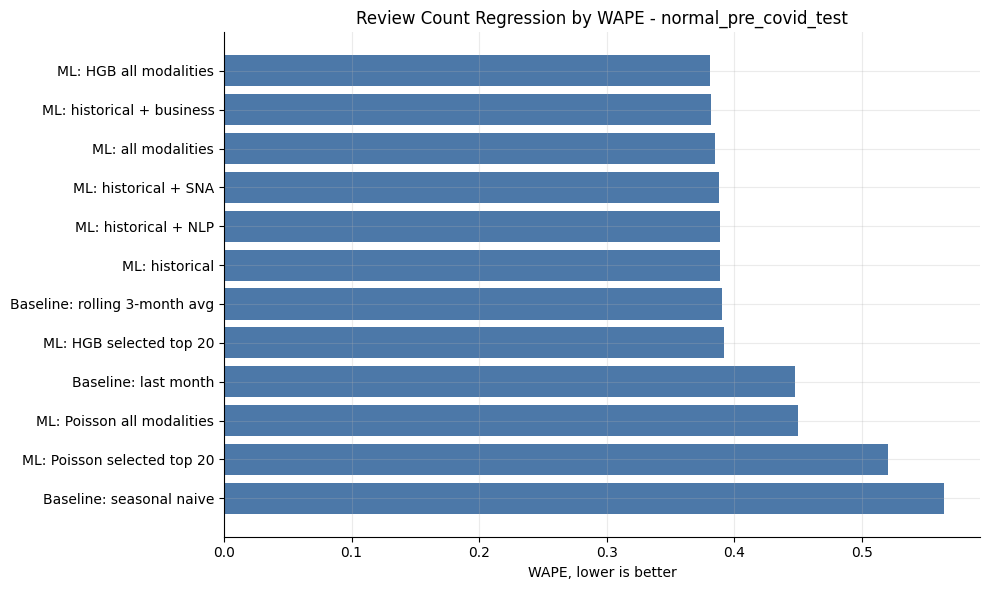

C:\Users\mehdi\OneDrive\Documents\community-forecasting-yelp\outputs\figures\models\review_count_wape_comparison_normal_pre_covid_test.png


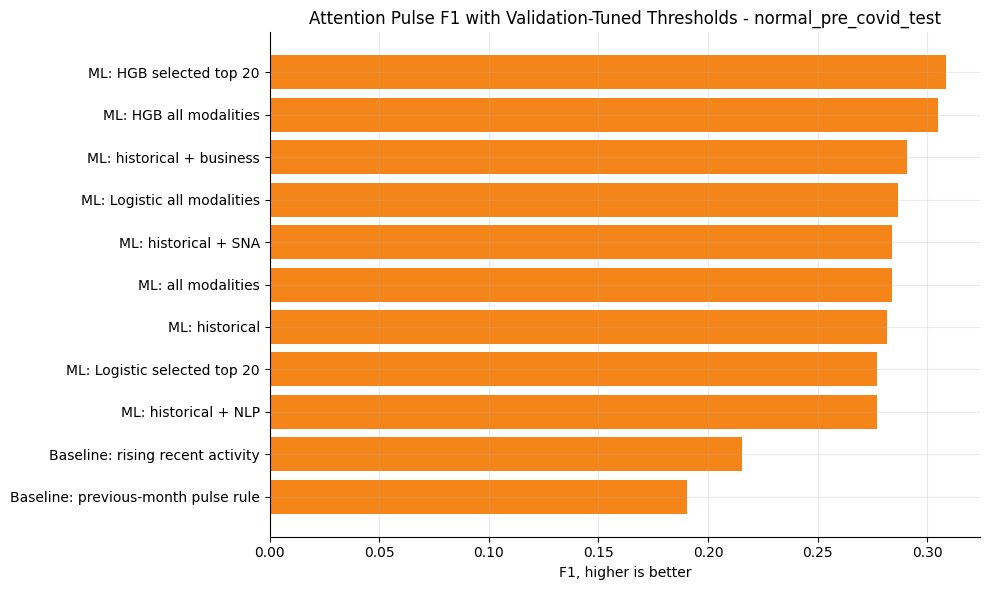

C:\Users\mehdi\OneDrive\Documents\community-forecasting-yelp\outputs\figures\models\attention_pulse_f1_comparison_normal_pre_covid_test.png


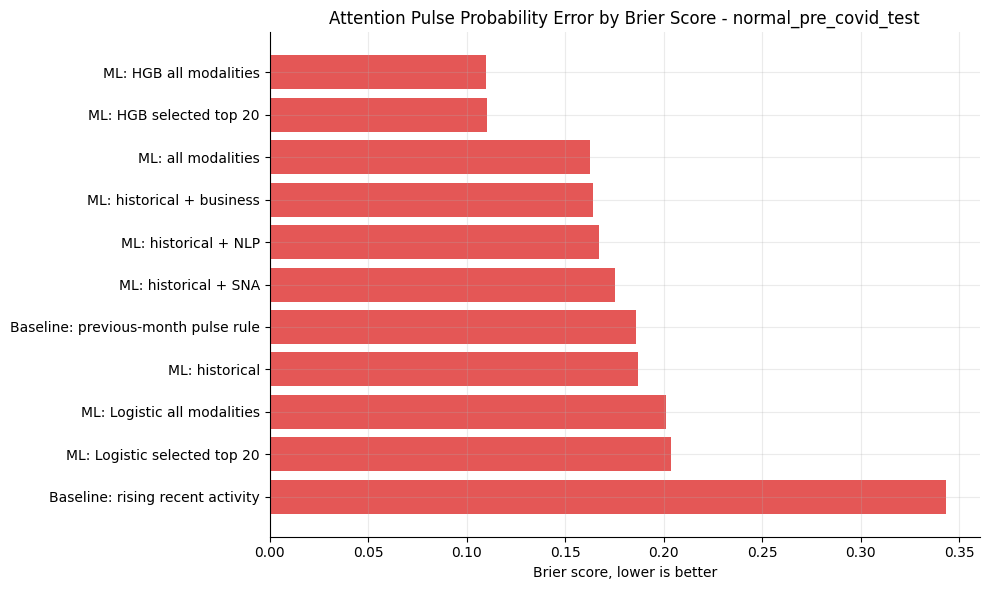

C:\Users\mehdi\OneDrive\Documents\community-forecasting-yelp\outputs\figures\models\attention_pulse_brier_comparison_normal_pre_covid_test.png


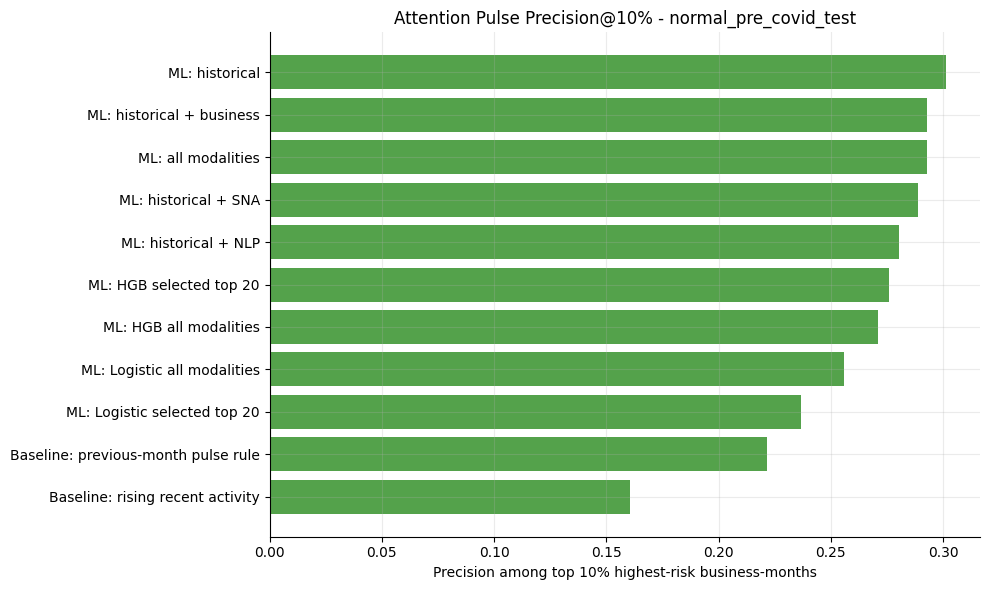

C:\Users\mehdi\OneDrive\Documents\community-forecasting-yelp\outputs\figures\models\attention_pulse_precision_at_10pct_normal_pre_covid_test.png


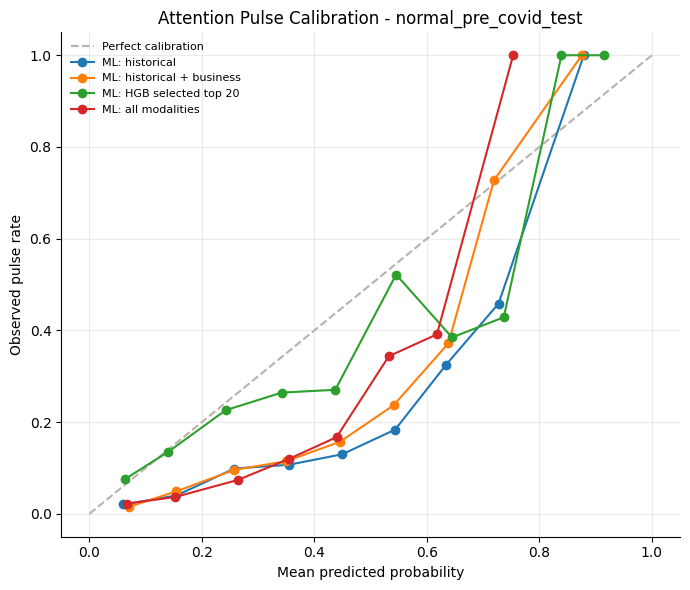

C:\Users\mehdi\OneDrive\Documents\community-forecasting-yelp\outputs\figures\models\attention_pulse_calibration_normal_pre_covid_test.png


In [5]:
# Save comparison figures for regression, pulse F1, calibration, and top-k ranking.
for split_name in metrics_df["split"].unique():
    split_metrics = metrics_df[metrics_df["split"] == split_name].sort_values("WAPE")
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(split_metrics["model"], split_metrics["WAPE"], color="#4C78A8")
    ax.invert_yaxis()
    ax.set_title(f"Review Count Regression by WAPE - {split_name}")
    ax.set_xlabel("WAPE, lower is better")
    fig.tight_layout()
    path = FIGURES_DIR / f"review_count_wape_comparison_{split_name}.png"
    fig.savefig(path, dpi=160)
    plt.show()
    plt.close(fig)
    print(path)

for split_name in pulse_metrics_df["split"].unique():
    split_metrics = pulse_metrics_df[pulse_metrics_df["split"] == split_name].sort_values("F1", ascending=False)
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(split_metrics["model"], split_metrics["F1"], color="#F58518")
    ax.invert_yaxis()
    ax.set_title(f"Attention Pulse F1 with Validation-Tuned Thresholds - {split_name}")
    ax.set_xlabel("F1, higher is better")
    fig.tight_layout()
    path = FIGURES_DIR / f"attention_pulse_f1_comparison_{split_name}.png"
    fig.savefig(path, dpi=160)
    plt.show()
    plt.close(fig)
    print(path)

for split_name in pulse_metrics_df["split"].unique():
    split_metrics = pulse_metrics_df[pulse_metrics_df["split"] == split_name].sort_values("Brier")
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(split_metrics["model"], split_metrics["Brier"], color="#E45756")
    ax.invert_yaxis()
    ax.set_title(f"Attention Pulse Probability Error by Brier Score - {split_name}")
    ax.set_xlabel("Brier score, lower is better")
    fig.tight_layout()
    path = FIGURES_DIR / f"attention_pulse_brier_comparison_{split_name}.png"
    fig.savefig(path, dpi=160)
    plt.show()
    plt.close(fig)
    print(path)

for split_name in pulse_topk_metrics_df["split"].unique():
    split_topk = pulse_topk_metrics_df[
        (pulse_topk_metrics_df["split"] == split_name)
        & (pulse_topk_metrics_df["k_fraction"] == 0.10)
    ].sort_values("precision_at_k", ascending=False)
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(split_topk["model"], split_topk["precision_at_k"], color="#54A24B")
    ax.invert_yaxis()
    ax.set_title(f"Attention Pulse Precision@10% - {split_name}")
    ax.set_xlabel("Precision among top 10% highest-risk business-months")
    fig.tight_layout()
    path = FIGURES_DIR / f"attention_pulse_precision_at_10pct_{split_name}.png"
    fig.savefig(path, dpi=160)
    plt.show()
    plt.close(fig)
    print(path)

for split_name in pulse_calibration_df["split"].unique():
    best_models = (
        pulse_metrics_df[pulse_metrics_df["split"] == split_name]
        .sort_values(["PR_AUC", "Brier"], ascending=[False, True])
        .head(4)["model"]
        .tolist()
    )
    fig, ax = plt.subplots(figsize=(7, 6))
    ax.plot([0, 1], [0, 1], color="#BAB0AC", linestyle="--", label="Perfect calibration")
    for model_name in best_models:
        line_df = pulse_calibration_df[(pulse_calibration_df["split"] == split_name) & (pulse_calibration_df["model"] == model_name)]
        ax.plot(line_df["mean_predicted_probability"], line_df["observed_pulse_rate"], marker="o", label=model_name)
    ax.set_title(f"Attention Pulse Calibration - {split_name}")
    ax.set_xlabel("Mean predicted probability")
    ax.set_ylabel("Observed pulse rate")
    ax.legend(frameon=False, fontsize=8)
    fig.tight_layout()
    path = FIGURES_DIR / f"attention_pulse_calibration_{split_name}.png"
    fig.savefig(path, dpi=160)
    plt.show()
    plt.close(fig)
    print(path)

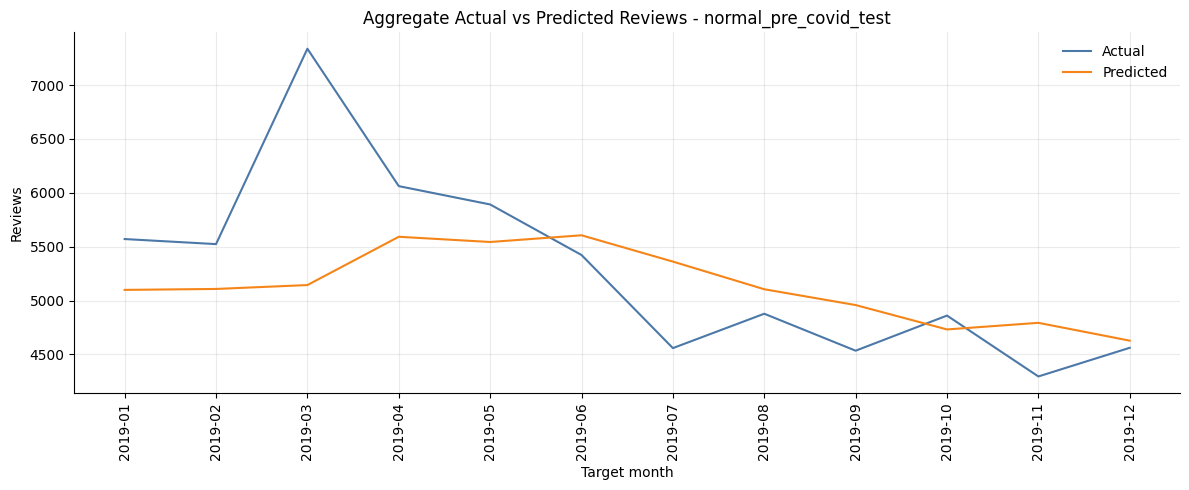

C:\Users\mehdi\OneDrive\Documents\community-forecasting-yelp\outputs\figures\models\review_count_actual_vs_predicted_normal_pre_covid_test.png


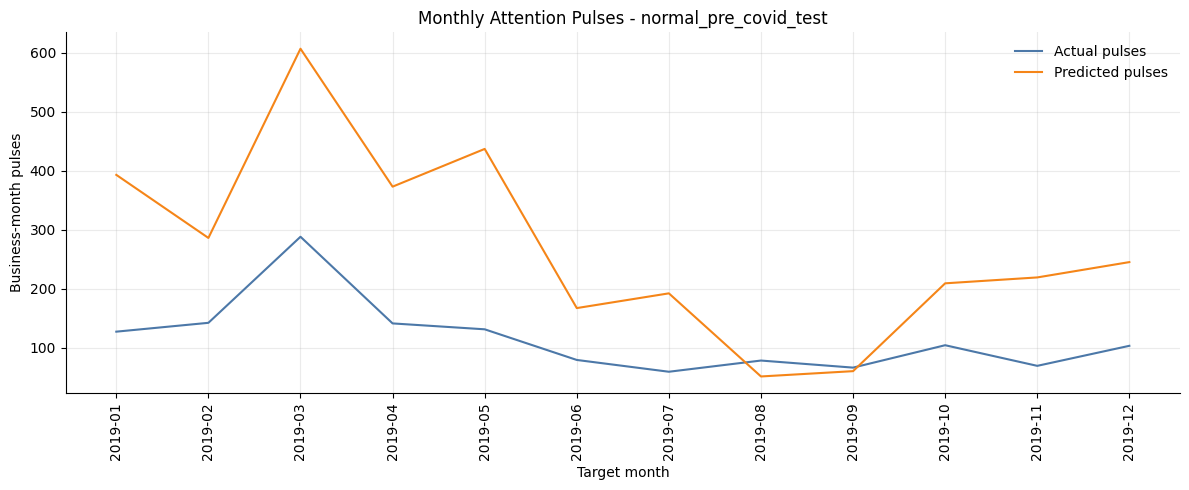

C:\Users\mehdi\OneDrive\Documents\community-forecasting-yelp\outputs\figures\models\attention_pulse_actual_vs_predicted_normal_pre_covid_test.png


In [6]:
# Save aggregate actual-vs-predicted figures for the selected comparison model.
comparison_model = "ML: HGB selected top 20"
fallback_model = "ML: all modalities"
if comparison_model not in set(predictions_df["model"]):
    comparison_model = fallback_model

for split_name in predictions_df["split"].unique():
    plot_df = predictions_df[(predictions_df["split"] == split_name) & (predictions_df["model"] == comparison_model)].copy()
    monthly = plot_df.groupby("target_month_str").agg(actual=("target_next_month_reviews", "sum"), predicted=("prediction", "sum")).reset_index()
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(monthly["target_month_str"], monthly["actual"], label="Actual", color="#4C78A8")
    ax.plot(monthly["target_month_str"], monthly["predicted"], label="Predicted", color="#F58518")
    ax.set_title(f"Aggregate Actual vs Predicted Reviews - {split_name}")
    ax.set_xlabel("Target month")
    ax.set_ylabel("Reviews")
    ax.tick_params(axis="x", rotation=90)
    ax.legend(frameon=False)
    fig.tight_layout()
    path = FIGURES_DIR / f"review_count_actual_vs_predicted_{split_name}.png"
    fig.savefig(path, dpi=160)
    plt.show()
    plt.close(fig)
    print(path)

for split_name in pulse_predictions_df["split"].unique():
    plot_df = pulse_predictions_df[(pulse_predictions_df["split"] == split_name) & (pulse_predictions_df["model"] == comparison_model)].copy()
    monthly = plot_df.groupby("target_month_str").agg(actual_pulses=("attention_pulse", "sum"), predicted_pulses=("prediction", "sum")).reset_index()
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(monthly["target_month_str"], monthly["actual_pulses"], label="Actual pulses", color="#4C78A8")
    ax.plot(monthly["target_month_str"], monthly["predicted_pulses"], label="Predicted pulses", color="#F58518")
    ax.set_title(f"Monthly Attention Pulses - {split_name}")
    ax.set_xlabel("Target month")
    ax.set_ylabel("Business-month pulses")
    ax.tick_params(axis="x", rotation=90)
    ax.legend(frameon=False)
    fig.tight_layout()
    path = FIGURES_DIR / f"attention_pulse_actual_vs_predicted_{split_name}.png"
    fig.savefig(path, dpi=160)
    plt.show()
    plt.close(fig)
    print(path)

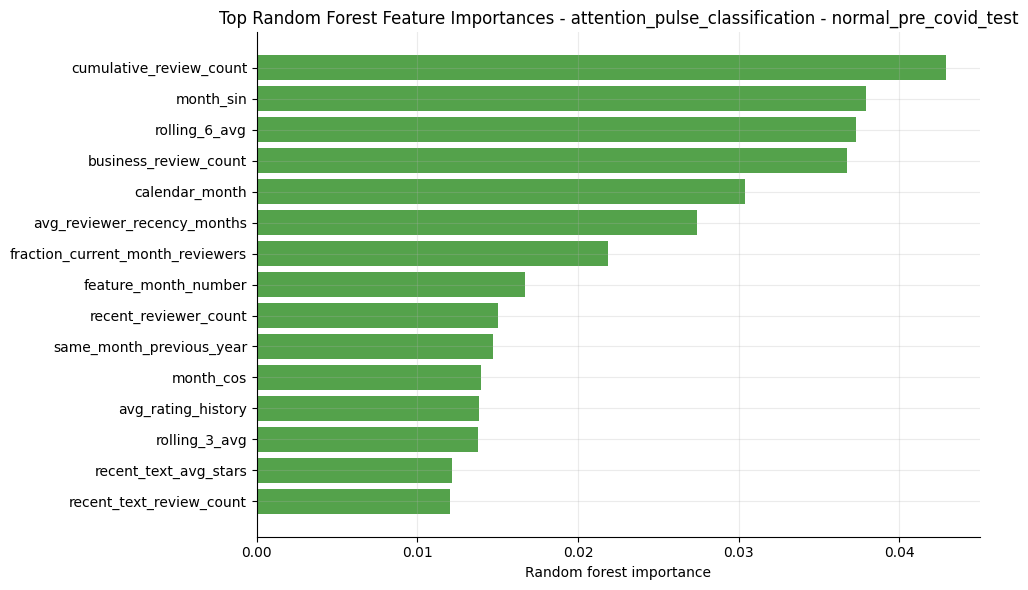

C:\Users\mehdi\OneDrive\Documents\community-forecasting-yelp\outputs\figures\models\attention_pulse_feature_importance_normal_pre_covid_test.png


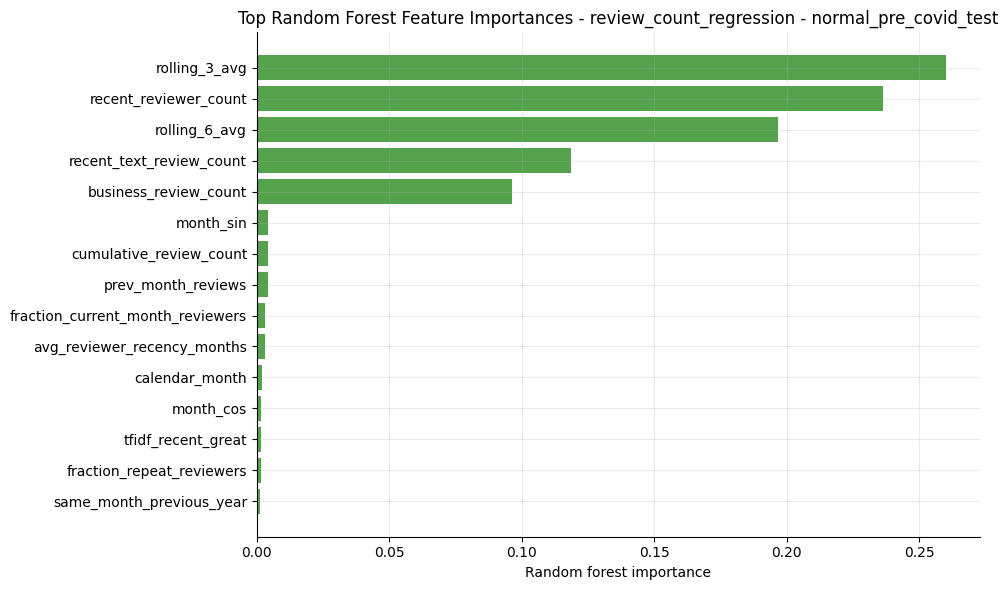

C:\Users\mehdi\OneDrive\Documents\community-forecasting-yelp\outputs\figures\models\review_count_feature_importance_normal_pre_covid_test.png


,task,split,feature,importance
104,attention_pulse_classification,normal_pre_covid_test,cumulative_review_count,0.042885
107,attention_pulse_classification,normal_pre_covid_test,month_sin,0.037912
102,attention_pulse_classification,normal_pre_covid_test,rolling_6_avg,0.037307
111,attention_pulse_classification,normal_pre_covid_test,business_review_count,0.036722
106,attention_pulse_classification,normal_pre_covid_test,calendar_month,0.030371
137,attention_pulse_classification,normal_pre_covid_test,avg_reviewer_recency_months,0.027436
138,attention_pulse_classification,normal_pre_covid_test,fraction_current_month_reviewers,0.021856
109,attention_pulse_classification,normal_pre_covid_test,feature_month_number,0.016703
116,attention_pulse_classification,normal_pre_covid_test,recent_reviewer_count,0.015034
103,attention_pulse_classification,normal_pre_covid_test,same_month_previous_year,0.014690


In [7]:
# Extract and plot Random Forest feature importances where available.
importance_rows = []
for (split_name, model_name), (model, features, family) in regression_models.items():
    if model_name != "ML: all modalities" or not hasattr(model, "feature_importances_"):
        continue
    for feature, importance in zip(features, model.feature_importances_):
        importance_rows.append({"task": "review_count_regression", "split": split_name, "feature": feature, "importance": importance})
for (split_name, model_name), (model, features, family, decision_threshold) in pulse_models.items():
    if model_name != "ML: all modalities" or not hasattr(model, "feature_importances_"):
        continue
    for feature, importance in zip(features, model.feature_importances_):
        importance_rows.append({"task": "attention_pulse_classification", "split": split_name, "feature": feature, "importance": importance})

importance_df = pd.DataFrame(importance_rows).sort_values(["task", "split", "importance"], ascending=[True, True, False])

for (task, split_name), group in importance_df.groupby(["task", "split"]):
    top_importance = group.head(15).sort_values("importance")
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(top_importance["feature"], top_importance["importance"], color="#54A24B")
    ax.set_title(f"Top Random Forest Feature Importances - {task} - {split_name}")
    ax.set_xlabel("Random forest importance")
    fig.tight_layout()
    safe_task = task.replace("_classification", "").replace("_regression", "")
    path = FIGURES_DIR / f"{safe_task}_feature_importance_{split_name}.png"
    fig.savefig(path, dpi=160)
    plt.show()
    plt.close(fig)
    print(path)

importance_df.head(20)

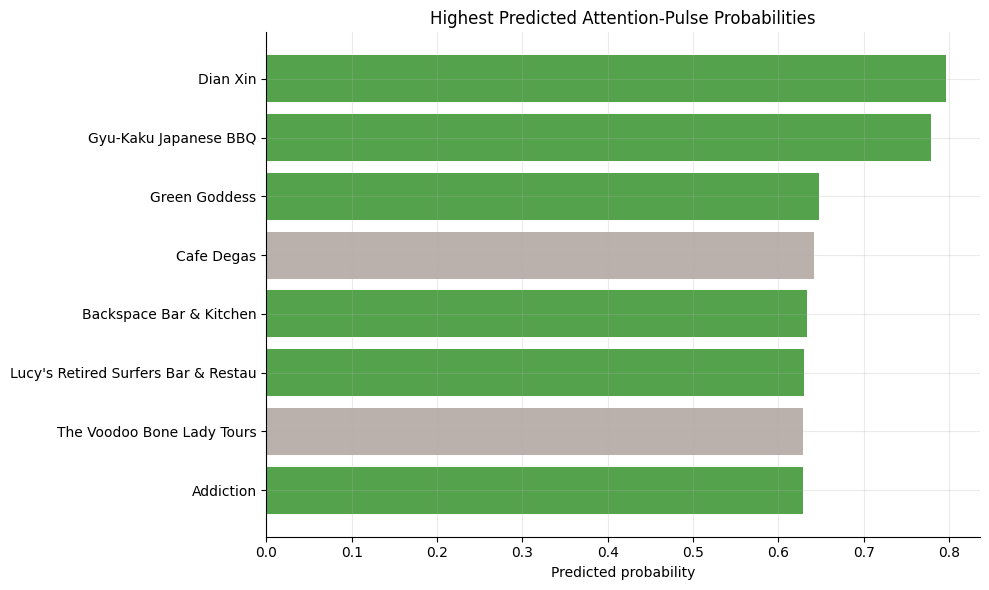

C:\Users\mehdi\OneDrive\Documents\community-forecasting-yelp\outputs\figures\models\attention_pulse_top_predicted_examples.png


,business_id,name,target_month_str,attention_pulse,target_next_month_reviews,pulse_baseline_reviews,pulse_relative_lift,probability
0,5xRmemqmR89BpGoOA25hqA,Dian Xin,2019-03,1,15.0,4.000000,3.750000,0.796435
1,yKAOohng_AJl22LgjBPl1g,Gyu-Kaku Japanese BBQ,2019-01,1,35.0,0.833333,35.000000,0.778967
2,5xRmemqmR89BpGoOA25hqA,Dian Xin,2019-02,1,23.0,0.166667,23.000000,0.733336
3,yKAOohng_AJl22LgjBPl1g,Gyu-Kaku Japanese BBQ,2019-02,1,22.0,6.666667,3.300000,0.704815
4,voWjA6zfmXLIbKAoqwBnug,Green Goddess,2019-03,1,21.0,6.833333,3.073171,0.648128
5,HUcjSm1Lxdn8zSu-hQ7-sw,Cafe Degas,2019-03,0,3.0,3.666667,0.818182,0.642178
6,rOsC1rDpIxvNoHxEvNFjeA,Backspace Bar & Kitchen,2019-03,1,9.0,4.333333,2.076923,0.633995
7,oLc7k78_YcDMnMCdbC-h1A,Lucy's Retired Surfers Bar & Restaurant,2019-03,1,9.0,4.666667,1.928571,0.629827
8,gmjsEdUsKpj9Xxu6pdjH0g,The Voodoo Bone Lady Tours,2019-03,0,4.0,3.666667,1.090909,0.629203
9,u0U5IQEQzQauLnP54rMUOA,Addiction,2019-04,1,9.0,0.166667,9.000000,0.628503


In [8]:
# Save high-probability attention-pulse examples for qualitative review.
example_split = "normal_pre_covid_test"
example_model = "ML: all modalities"
examples = (
    pulse_predictions_df[(pulse_predictions_df["split"] == example_split) & (pulse_predictions_df["model"] == example_model)]
    .sort_values("probability", ascending=False)
    .head(10)
    .merge(business_lookup, on="business_id", how="left")
)

fig, ax = plt.subplots(figsize=(10, 6))
labels = examples["name"].fillna(examples["business_id"]).str.slice(0, 35)
colors = np.where(examples["attention_pulse"].eq(1), "#54A24B", "#BAB0AC")
ax.barh(labels[::-1], examples["probability"].values[::-1], color=colors[::-1])
ax.set_title("Highest Predicted Attention-Pulse Probabilities")
ax.set_xlabel("Predicted probability")
fig.tight_layout()
path = FIGURES_DIR / "attention_pulse_top_predicted_examples.png"
fig.savefig(path, dpi=160)
plt.show()
plt.close(fig)
print(path)

examples[["business_id", "name", "target_month_str", "attention_pulse", "target_next_month_reviews", "pulse_baseline_reviews", "pulse_relative_lift", "probability"]]

## Prophet Benchmark for Top Businesses

Fit a business-level Prophet model for each of the top 10 businesses by total monthly review count. This benchmark uses only each business's own monthly review history, with yearly seasonality enabled and weekly/daily seasonality disabled. The train period is 2015-2017 and the held-out normal-period test year is 2019.

In [9]:
# Fit Prophet models for the top-10 businesses by observed monthly review volume.
import logging

try:
    from prophet import Prophet
except ImportError as exc:
    raise ImportError("Install Prophet with `pip install prophet` before running this section.") from exc

logging.getLogger("cmdstanpy").setLevel(logging.WARNING)

PROPHET_TRAIN_START = pd.Timestamp("2015-01-01")
PROPHET_TRAIN_END = pd.Timestamp("2017-12-01")
PROPHET_TEST_START = pd.Timestamp("2019-01-01")
PROPHET_TEST_END = pd.Timestamp("2019-12-01")

if {"year_month", "review_count"}.issubset(modeling.columns):
    month_column = "year_month"
    count_column = "review_count"
elif {"target_month_str", "target_next_month_reviews"}.issubset(modeling.columns):
    month_column = "target_month_str"
    count_column = "target_next_month_reviews"
elif {"feature_month_str", "monthly_review_count"}.issubset(modeling.columns):
    month_column = "feature_month_str"
    count_column = "monthly_review_count"
else:
    raise ValueError("Prophet section needs year_month/review_count or the notebook's monthly target columns.")


prophet_series = (
    modeling[["business_id", month_column, count_column]]
    .rename(columns={month_column: "ds", count_column: "y"})
    .assign(ds=lambda df: pd.to_datetime(df["ds"]).dt.to_period("M").dt.to_timestamp(), y=lambda df: df["y"].astype(float))
    .groupby(["business_id", "ds"], as_index=False)["y"]
    .sum()
)
prophet_series = prophet_series[(prophet_series["ds"] >= PROPHET_TRAIN_START) & (prophet_series["ds"] <= PROPHET_TEST_END)]

top10_business_ids = (
    prophet_series.groupby("business_id")["y"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .index
    .tolist()
)
business_names = business_lookup.drop_duplicates("business_id").set_index("business_id")["name"].to_dict()

prophet_models = {}
prophet_forecasts = {}
prophet_prediction_frames = []
prophet_business_metrics = []
skipped_prophet_businesses = []

for business_id in top10_business_ids:
    business_series = prophet_series[prophet_series["business_id"] == business_id].sort_values("ds")
    train_series = business_series[(business_series["ds"] >= PROPHET_TRAIN_START) & (business_series["ds"] <= PROPHET_TRAIN_END)][["ds", "y"]]
    test_series = business_series[(business_series["ds"] >= PROPHET_TEST_START) & (business_series["ds"] <= PROPHET_TEST_END)][["ds", "y"]]

    if len(train_series) < 24 or test_series.empty:
        skipped_prophet_businesses.append(business_id)
        continue

    model = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
    model.fit(train_series)

    future = pd.DataFrame({"ds": pd.date_range(train_series["ds"].min(), PROPHET_TEST_END, freq="MS")})
    forecast = model.predict(future)
    forecast_columns = ["ds", "yhat", "yhat_lower", "yhat_upper", "trend", "yearly"]
    business_predictions = test_series.merge(forecast[forecast_columns], on="ds", how="left")
    business_predictions["yhat"] = np.clip(business_predictions["yhat"], 0, None)
    business_predictions = business_predictions.assign(
        business_id=business_id,
        name=business_names.get(business_id, business_id),
        model="Prophet",
    )

    prophet_models[business_id] = model
    prophet_forecasts[business_id] = forecast
    prophet_prediction_frames.append(business_predictions)
    prophet_business_metrics.append({
        "business_id": business_id,
        "name": business_names.get(business_id, business_id),
        "train_months": len(train_series),
        "test_months": len(test_series),
        "MAE": mean_absolute_error(business_predictions["y"], business_predictions["yhat"]),
        "RMSE": mean_squared_error(business_predictions["y"], business_predictions["yhat"]) ** 0.5,
    })

if skipped_prophet_businesses:
    print(f"Skipped Prophet fits for insufficient coverage: {skipped_prophet_businesses}")

prophet_predictions = pd.concat(prophet_prediction_frames, ignore_index=True)
prophet_summary = pd.DataFrame(prophet_business_metrics).sort_values("RMSE").reset_index(drop=True)
prophet_summary

C:\Users\mehdi\OneDrive\Documents\community-forecasting-yelp\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


15:59:33 - cmdstanpy - INFO - Chain [1] start processing


15:59:33 - cmdstanpy - INFO - Chain [1] done processing


15:59:33 - cmdstanpy - INFO - Chain [1] start processing


15:59:34 - cmdstanpy - INFO - Chain [1] done processing


...

15:59:37 - cmdstanpy - INFO - Chain [1] start processing


15:59:38 - cmdstanpy - INFO - Chain [1] done processing


15:59:38 - cmdstanpy - INFO - Chain [1] start processing


15:59:38 - cmdstanpy - INFO - Chain [1] done processing


,business_id,name,train_months,test_months,MAE,RMSE
0,GBTPC53ZrG1ZBY3DT8Mbcw,Luke,35,12,8.323513,9.825147
1,_C7QiQQc47AOEv4PE3Kong,Commander's Palace,35,12,8.653365,10.227640
2,iSRTaT9WngzB8JJ2YKJUig,Mother's Restaurant,35,12,7.783975,10.330692
3,oBNrLz4EDhiscSlbOl8uAw,Ruby Slipper - New Orleans,35,12,12.923479,15.223642
4,qb28j-FNX1_6xm7u372TZA,Gumbo Shop,35,12,13.806975,15.495538
5,6a4gLLFSgr-Q6CZXDLzBGQ,Cochon,35,12,12.599261,15.909711
6,VaO-VW3e1kARkU9bP1E7Fw,Felix's Restaurant & Oyster Bar,35,12,13.350531,16.190440
7,_ab50qdWOk0DdB6XOrBitw,Acme Oyster House,35,12,17.469261,20.718430
8,VQcCL9PiNL_wkGf-uF3fjg,Royal House,35,12,17.872785,21.334268
9,ac1AeYqs8Z4_e2X5M3if2A,Oceana Grill,35,12,30.925833,34.453361


In [10]:
# Append a scoped Prophet aggregate row to the forecasting metrics output and compare against ML on the same top-10 businesses.
prophet_actual = prophet_predictions["y"].astype(float)
prophet_pred = prophet_predictions["yhat"].astype(float)
prophet_aggregate_row = {
    "split": "normal_pre_covid_test",
    "task": "review_count_regression_top10",
    "model": "Prophet",
    "model_name": "Prophet",
    "train_period": "2015-01 to 2017-12",
    "validation_period": "not used",
    "test_period": "2019-01 to 2019-12",
    "rows": len(prophet_predictions),
    "MAE": mean_absolute_error(prophet_actual, prophet_pred),
    "RMSE": mean_squared_error(prophet_actual, prophet_pred) ** 0.5,
    "WAPE": wape(prophet_actual.values, prophet_pred.values),
    "model_family": "Prophet",
    "feature_count": 0,
    "business_count": prophet_predictions["business_id"].nunique(),
    "scope": "top_10_businesses_by_total_reviews",
}

existing_metrics = pd.read_csv(METRICS_OUTPUT_PATH) if METRICS_OUTPUT_PATH.exists() else metrics_df.copy()
if "model_name" not in existing_metrics.columns:
    existing_metrics["model_name"] = existing_metrics["model"] if "model" in existing_metrics.columns else np.nan
for column in prophet_aggregate_row:
    if column not in existing_metrics.columns:
        existing_metrics[column] = np.nan

prophet_row_df = pd.DataFrame([prophet_aggregate_row])
for column in existing_metrics.columns:
    if column not in prophet_row_df.columns:
        prophet_row_df[column] = np.nan
prophet_row_df = prophet_row_df[existing_metrics.columns]

metric_model = existing_metrics["model"].astype(str) if "model" in existing_metrics.columns else pd.Series("", index=existing_metrics.index)
metric_model_name = existing_metrics["model_name"].astype(str) if "model_name" in existing_metrics.columns else pd.Series("", index=existing_metrics.index)
prophet_metric_mask = (
    ((metric_model == "Prophet") | (metric_model_name == "Prophet"))
    & (existing_metrics["split"] == "normal_pre_covid_test")
    & (existing_metrics["task"] == "review_count_regression_top10")
)
updated_metrics = pd.concat([existing_metrics.loc[~prophet_metric_mask], prophet_row_df], ignore_index=True)
updated_metrics.to_csv(METRICS_OUTPUT_PATH, index=False)

prophet_summary.to_csv(OUTPUTS_DIR / "prophet_top10_business_metrics.csv", index=False)
prophet_predictions.to_csv(OUTPUTS_DIR / "prophet_top10_predictions.csv", index=False)

top10_id_set = set(top10_business_ids)
top10_ml_predictions = predictions_df[
    (predictions_df["split"] == "normal_pre_covid_test")
    & (predictions_df["business_id"].isin(top10_id_set))
].copy()

comparison_rows = [{
    "model": "Prophet",
    "scope": "top-10 businesses",
    "rows": len(prophet_predictions),
    "MAE": prophet_aggregate_row["MAE"],
    "RMSE": prophet_aggregate_row["RMSE"],
    "WAPE": prophet_aggregate_row["WAPE"],
}]
for model_name, group in top10_ml_predictions.groupby("model"):
    y_true = group["target_next_month_reviews"].astype(float).values
    y_pred = np.clip(group["prediction"].astype(float).values, 0, None)
    comparison_rows.append({
        "model": model_name,
        "scope": "same top-10 businesses",
        "rows": len(group),
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": mean_squared_error(y_true, y_pred) ** 0.5,
        "WAPE": wape(y_true, y_pred),
    })

prophet_ml_comparison = pd.DataFrame(comparison_rows).sort_values(["RMSE", "MAE"]).reset_index(drop=True)
prophet_ml_comparison.to_csv(OUTPUTS_DIR / "prophet_top10_ml_comparison.csv", index=False)
prophet_ml_comparison

,model,scope,rows,MAE,RMSE,WAPE
0,Baseline: rolling 3-month avg,same top-10 businesses,120,10.138889,12.988171,0.162287
1,Baseline: last month,same top-10 businesses,120,12.116667,15.188263,0.193944
2,Prophet,top-10 businesses,120,14.370898,18.347806,0.230026
3,Baseline: seasonal naive,same top-10 businesses,120,16.883333,21.427786,0.270241
4,ML: HGB all modalities,same top-10 businesses,120,14.025126,21.504771,0.224492
5,ML: historical + SNA,same top-10 businesses,120,14.347530,22.114691,0.229652
6,ML: all modalities,same top-10 businesses,120,14.467253,22.342952,0.231569
7,ML: historical + NLP,same top-10 businesses,120,14.186198,22.345508,0.227070
8,ML: historical,same top-10 businesses,120,14.444702,22.413335,0.231208
9,ML: historical + business,same top-10 businesses,120,14.689078,22.555587,0.235119


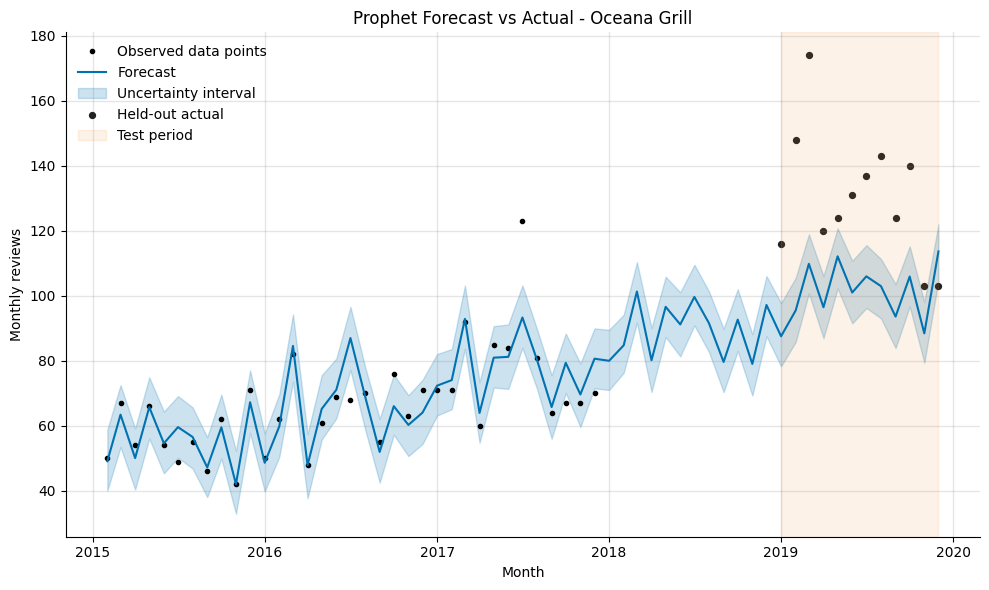

C:\Users\mehdi\OneDrive\Documents\community-forecasting-yelp\outputs\figures\models\prophet_forecast_ac1AeYqs8Z4_e2X5M3if2A.png


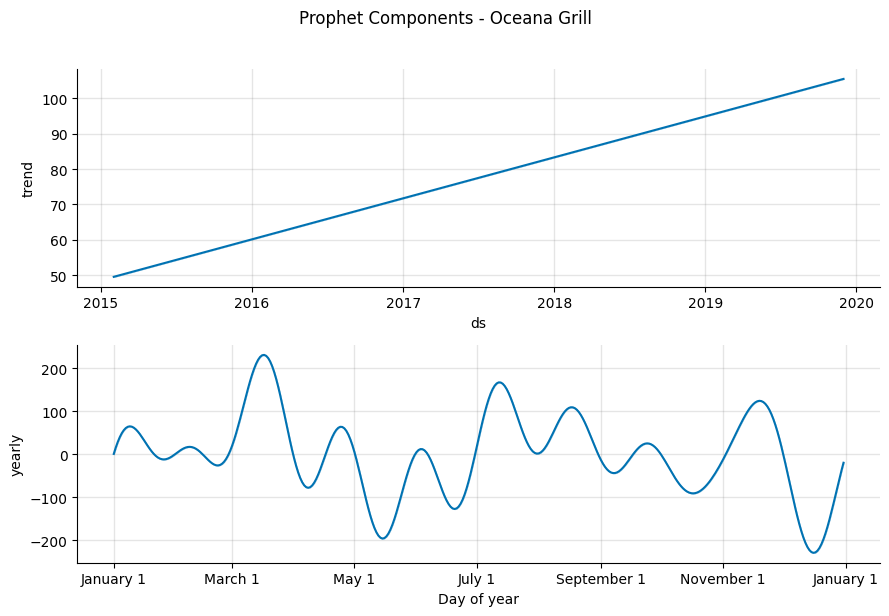

C:\Users\mehdi\OneDrive\Documents\community-forecasting-yelp\outputs\figures\models\prophet_components_ac1AeYqs8Z4_e2X5M3if2A.png


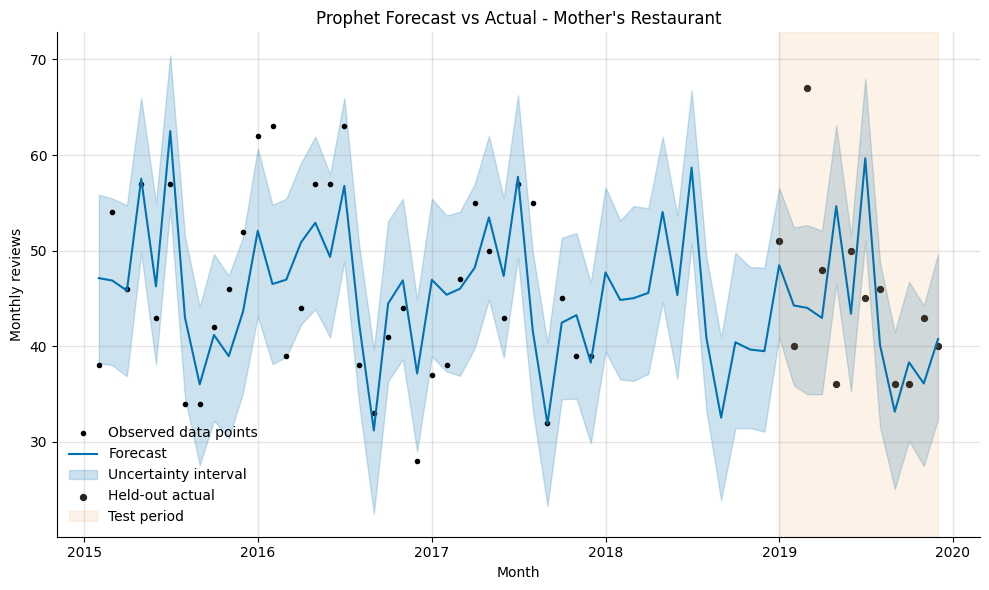

C:\Users\mehdi\OneDrive\Documents\community-forecasting-yelp\outputs\figures\models\prophet_forecast_iSRTaT9WngzB8JJ2YKJUig.png


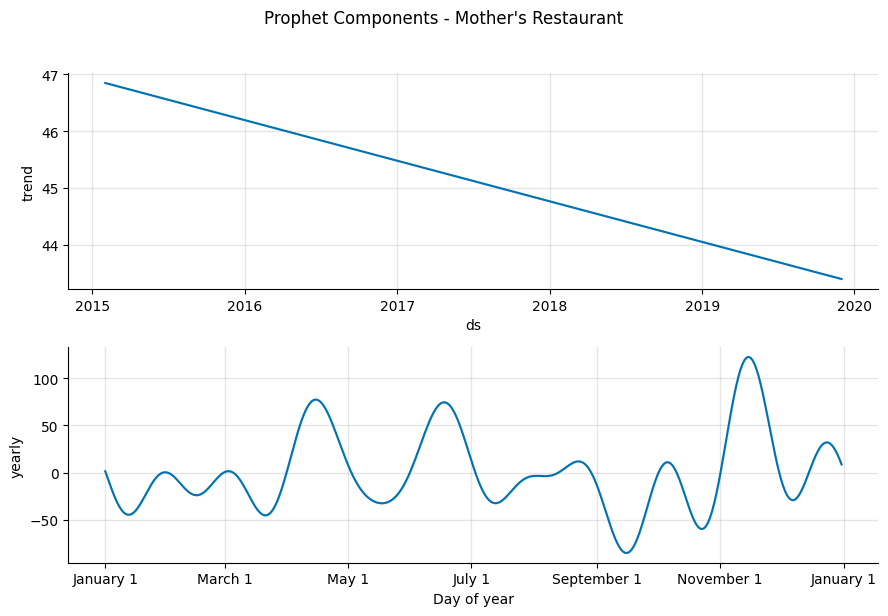

C:\Users\mehdi\OneDrive\Documents\community-forecasting-yelp\outputs\figures\models\prophet_components_iSRTaT9WngzB8JJ2YKJUig.png


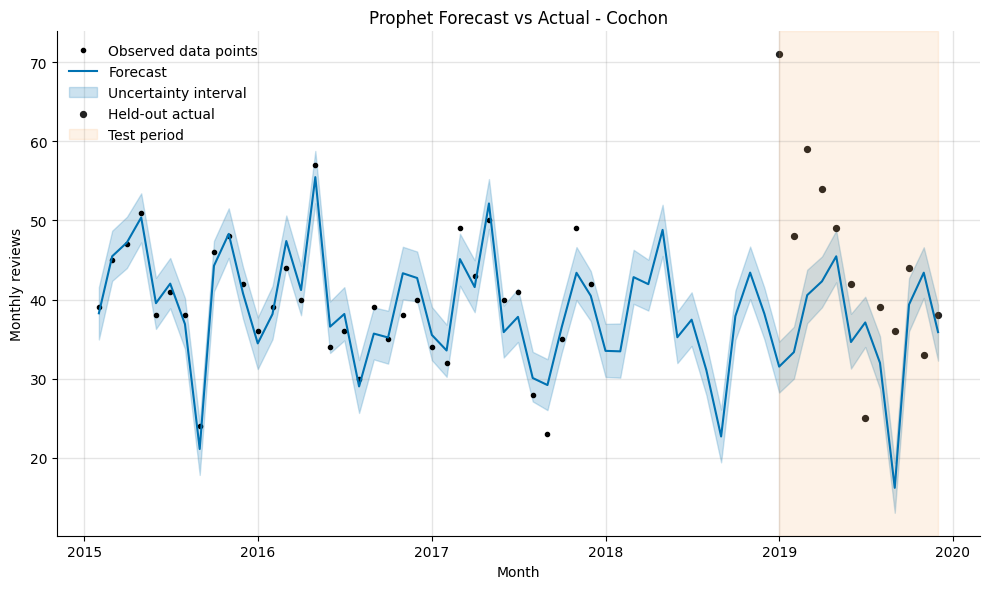

C:\Users\mehdi\OneDrive\Documents\community-forecasting-yelp\outputs\figures\models\prophet_forecast_6a4gLLFSgr_Q6CZXDLzBGQ.png


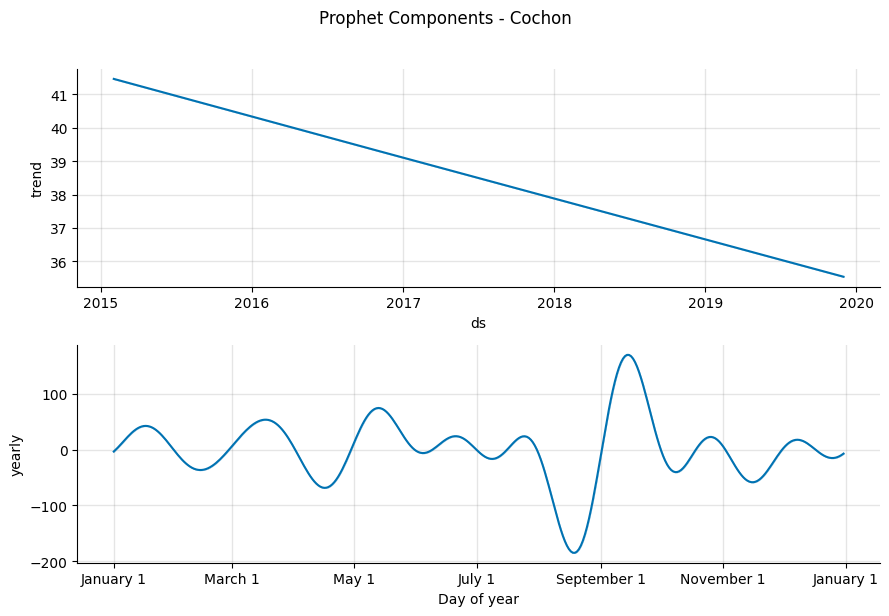

C:\Users\mehdi\OneDrive\Documents\community-forecasting-yelp\outputs\figures\models\prophet_components_6a4gLLFSgr_Q6CZXDLzBGQ.png


In [11]:
# Plot Prophet forecasts and built-in trend/seasonality decompositions for representative top businesses.
representative_positions = [0, len(top10_business_ids) // 2, len(top10_business_ids) - 1]
representative_business_ids = []
for position in representative_positions:
    candidate = top10_business_ids[position]
    if candidate in prophet_models and candidate not in representative_business_ids:
        representative_business_ids.append(candidate)

for business_id in representative_business_ids:
    model = prophet_models[business_id]
    forecast = prophet_forecasts[business_id]
    name = business_names.get(business_id, business_id)
    safe_business_id = "".join(character if character.isalnum() else "_" for character in business_id)

    business_actual = prophet_series[prophet_series["business_id"] == business_id]
    test_actual = business_actual[(business_actual["ds"] >= PROPHET_TEST_START) & (business_actual["ds"] <= PROPHET_TEST_END)]
    fig = model.plot(forecast, xlabel="Month", ylabel="Monthly reviews")
    ax = fig.axes[0]
    ax.scatter(test_actual["ds"], test_actual["y"], color="#222222", s=18, label="Held-out actual")
    ax.axvspan(PROPHET_TEST_START, PROPHET_TEST_END, color="#F58518", alpha=0.10, label="Test period")
    ax.set_title(f"Prophet Forecast vs Actual - {name}")
    ax.legend(frameon=False)
    fig.tight_layout()
    forecast_path = FIGURES_DIR / f"prophet_forecast_{safe_business_id}.png"
    fig.savefig(forecast_path, dpi=160)
    plt.show()
    plt.close(fig)
    print(forecast_path)

    component_fig = model.plot_components(forecast)
    component_fig.suptitle(f"Prophet Components - {name}", y=1.02)
    component_fig.tight_layout()
    components_path = FIGURES_DIR / f"prophet_components_{safe_business_id}.png"
    component_fig.savefig(components_path, dpi=160, bbox_inches="tight")
    plt.show()
    plt.close(component_fig)
    print(components_path)

## Community-Level Prophet Forecasts

Evaluate whether the five largest reviewer communities have forecastable aggregate review rhythms. This uses the same Prophet configuration as the business-level benchmark (`yearly_seasonality=True`, `weekly_seasonality=False`, `daily_seasonality=False`) and reuses the same train/test dates, so the community MAE is read against the same normal pre-COVID holdout period.

In [ ]:
# Fit a Prophet model per top reviewer community and report MAE on the same holdout as the business Prophet benchmark.
import logging

IN_NOTEBOOK = "get_ipython" in globals()
if not IN_NOTEBOOK:
    plt.switch_backend("Agg")

try:
    from prophet import Prophet
except ImportError as exc:
    raise ImportError("Install Prophet with `pip install prophet` before running this section.") from exc

for logger_name in ["cmdstanpy", "prophet"]:
    logger = logging.getLogger(logger_name)
    logger.setLevel(logging.ERROR)
    logger.disabled = True

COMMUNITY_MONTH_SERIES_PATH = PROCESSED_DIR / "community_month_series.csv"
COMMUNITY_PROPHET_METRICS_PATH = OUTPUTS_DIR / "community_prophet_metrics.csv"
COMMUNITY_PROPHET_PREDICTIONS_PATH = OUTPUTS_DIR / "community_prophet_predictions.csv"
COMMUNITY_PROPHET_TRAIN_START = PROPHET_TRAIN_START if "PROPHET_TRAIN_START" in globals() else pd.Timestamp("2015-01-01")
COMMUNITY_PROPHET_TRAIN_END = PROPHET_TRAIN_END if "PROPHET_TRAIN_END" in globals() else pd.Timestamp("2017-12-01")
COMMUNITY_PROPHET_TEST_START = PROPHET_TEST_START if "PROPHET_TEST_START" in globals() else pd.Timestamp("2019-01-01")
COMMUNITY_PROPHET_TEST_END = PROPHET_TEST_END if "PROPHET_TEST_END" in globals() else pd.Timestamp("2019-12-01")

community_series = pd.read_csv(COMMUNITY_MONTH_SERIES_PATH)
if community_series["is_top5_community"].dtype != bool:
    community_series["is_top5_community"] = community_series["is_top5_community"].astype(str).str.lower().eq("true")
community_series = community_series[community_series["is_top5_community"]].copy()
community_series["ds"] = pd.to_datetime(community_series["year_month"]).dt.to_period("M").dt.to_timestamp()
community_series["y"] = community_series["total_reviews"].astype(float)
community_series["community_id"] = community_series["community_id"].astype(int)

top5_community_ids = (
    community_series[["community_id", "community_size"]]
    .drop_duplicates()
    .sort_values("community_size", ascending=False)["community_id"]
    .tolist()
)
community_size_lookup = community_series.drop_duplicates("community_id").set_index("community_id")["community_size"].astype(int).to_dict()

community_prophet_models = {}
community_prophet_forecasts = {}
community_prophet_prediction_frames = []
community_prophet_metric_rows = []
skipped_community_forecasts = []

for community_id in top5_community_ids:
    one_community = community_series[community_series["community_id"].eq(community_id)].sort_values("ds")
    train_series = one_community[
        (one_community["ds"] >= COMMUNITY_PROPHET_TRAIN_START)
        & (one_community["ds"] <= COMMUNITY_PROPHET_TRAIN_END)
    ][["ds", "y"]]
    test_series = one_community[
        (one_community["ds"] >= COMMUNITY_PROPHET_TEST_START)
        & (one_community["ds"] <= COMMUNITY_PROPHET_TEST_END)
    ][["ds", "y"]]

    if len(train_series) < 24 or test_series.empty:
        skipped_community_forecasts.append(community_id)
        continue

    model = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
    model.fit(train_series)

    future = pd.DataFrame({"ds": pd.date_range(train_series["ds"].min(), COMMUNITY_PROPHET_TEST_END, freq="MS")})
    forecast = model.predict(future)
    forecast_columns = ["ds", "yhat", "yhat_lower", "yhat_upper"]
    community_predictions = test_series.merge(forecast[forecast_columns], on="ds", how="left")
    community_predictions["yhat"] = community_predictions["yhat"].clip(lower=0)
    community_predictions["absolute_error"] = (community_predictions["y"] - community_predictions["yhat"]).abs()
    community_predictions["community_id"] = community_id
    community_predictions["community_size"] = community_size_lookup[community_id]

    community_prophet_models[community_id] = model
    community_prophet_forecasts[community_id] = forecast
    community_prophet_prediction_frames.append(community_predictions)
    community_prophet_metric_rows.append({
        "community_id": community_id,
        "community_size": community_size_lookup[community_id],
        "train_months": len(train_series),
        "test_months": len(test_series),
        "test_total_reviews": float(community_predictions["y"].sum()),
        "MAE": float(community_predictions["absolute_error"].mean()),
        "RMSE": float(((community_predictions["y"] - community_predictions["yhat"]) ** 2).mean() ** 0.5),
        "WAPE": float(
            community_predictions["absolute_error"].sum()
            / community_predictions["y"].abs().sum()
        ),
    })

    fig, ax = plt.subplots(figsize=(11, 5))
    actual = one_community[
        (one_community["ds"] >= COMMUNITY_PROPHET_TRAIN_START)
        & (one_community["ds"] <= COMMUNITY_PROPHET_TEST_END)
    ]
    ax.plot(actual["ds"], actual["y"], color="#222222", label="Actual total reviews")
    ax.plot(forecast["ds"], forecast["yhat"].clip(lower=0), color="#4C78A8", label="Prophet forecast")
    ax.axvspan(
        COMMUNITY_PROPHET_TEST_START,
        COMMUNITY_PROPHET_TEST_END,
        color="#F58518",
        alpha=0.12,
        label=f"{COMMUNITY_PROPHET_TEST_START:%Y-%m} to {COMMUNITY_PROPHET_TEST_END:%Y-%m} test period",
    )
    ax.set_title(f"Community {community_id} Prophet Forecast vs Actual")
    ax.set_xlabel("Month")
    ax.set_ylabel("Total reviews")
    ax.legend(frameon=False)
    fig.tight_layout()
    forecast_path = FIGURES_DIR / f"community_forecast_{community_id}.png"
    fig.savefig(forecast_path, dpi=160)
    if IN_NOTEBOOK:
        plt.show()
    plt.close(fig)
    print(forecast_path)

if skipped_community_forecasts:
    print(f"Skipped communities with insufficient coverage: {skipped_community_forecasts}")

community_prophet_metrics = pd.DataFrame(community_prophet_metric_rows).sort_values("MAE").reset_index(drop=True)
community_prophet_predictions = pd.concat(community_prophet_prediction_frames, ignore_index=True)
community_prophet_metrics.to_csv(COMMUNITY_PROPHET_METRICS_PATH, index=False)
community_prophet_predictions.to_csv(COMMUNITY_PROPHET_PREDICTIONS_PATH, index=False)
community_prophet_metrics


### Community Forecast Interpretation

The community-level Prophet models forecast smoother aggregate series than individual businesses because aggregation reduces idiosyncratic business-month noise, but they are not uniformly easier in relative-error terms. On the normal pre-COVID 2019 holdout, MAE ranges from about 27 monthly reviews for community `45` to about 153 for community `42`; normalized WAPE is lowest for high-volume community `0` and highest for community `42`, whose trajectory is harder to extrapolate.

The interpretation is therefore modest: community forecasts are good for reading broad reviewer-group rhythms and for diagnosing later disruption, while business-level models remain the better unit for actionable attention forecasts.

### Prophet Compared with the ML Models

The Prophet row is a deliberately scoped top-10-business benchmark, while the main ML regression table evaluates the full business-month cohort. The `prophet_ml_comparison` table compares Prophet against the existing ML predictions on the same top-10 businesses so RMSE, MAE, and WAPE are read on a like-for-like subset.

On that top-10 subset, the rolling 3-month average is still the strongest benchmark by WAPE and RMSE. Prophet is useful because it provides an interpretable trend/seasonality decomposition and beats most ML variants on RMSE in this scoped comparison, but it does not beat the simple rolling baseline. This is an important structural result: for very high-volume businesses, recent history alone is hard to improve on; the richer ML feature set is more defensible for full-cohort modeling and pulse interpretation than as a universal replacement for temporal baselines.

## Modeling Limitations

- The reported main metrics estimate ordinary pre-COVID forecast performance, not robustness to the 2020-2021 disruption.
- Stronger model families do not guarantee better community insight; simple rolling baselines remain essential and are especially strong for high-volume businesses.
- The Prophet benchmark is scoped to the top 10 businesses and should not be read as a full-cohort model comparison.
- Community-level Prophet models smooth noise but lose business-level actionability, and their errors are not directly comparable to individual business-month errors without normalization.
- Pulse classification is a rare-event problem, so accuracy is less informative than F1, PR-AUC, calibration, and top-k retrieval metrics.
- TF-IDF features are deliberately capped and exploratory; they should be interpreted as recent language/topic indicators, not full NLP understanding.

## Modeling Takeaways

- The corrected evaluation uses one normal-period chronological split: train on 2015-2017, validate on 2018, and test on 2019.
- Review-count regression compares temporal baselines, Random Forest ablations, HistGradientBoosting, Poisson count models, selected-feature variants, and a scoped Prophet benchmark for the top businesses.
- The best full-cohort count model is all-modality HGB, but its gain over historical/business features and the rolling baseline is modest, so the result should be framed as learnable-but-noisy rather than decisive dominance.
- Attention-pulse classifiers use validation-tuned decision thresholds instead of the default `0.5` cutoff.
- Selected HGB gives the strongest thresholded pulse F1, while top-k retrieval shows that simpler historical/RF rankings remain competitive for surfacing likely pulse candidates.
- NLP model groups include VADER monthly sentiment features alongside text-length, lexicon, and capped TF-IDF signals.
- Community-level Prophet forecasts add a group-rhythm view of Yelp attention, but business-month forecasts remain the actionable target.
- Probability diagnostics are reported with Brier score and calibration curves because pulse probabilities are only useful if they behave like meaningful risk estimates.